In [88]:
cd("../p1");

In [256]:
%%file mk_p1.m

function y=mk_p1()
   fa=struct();

   p1_feladatok=struct();

   fa.id="f1";
   fa.equation="y'=\sin(t)+y";
   fa.rhs="@(t,y) sin(t)+y";
   fa.ivp=[-3,-3,-3;0.55,0.7,1];
   fa.domain=[-3,3;-3,10];
   p1_feladatok.f1=fa;

   fa.id="f2";
   fa.equation="y'=t^2-t-y";
   fa.rhs="@(t,y) t.^2-t-y";
   fa.ivp=[-3,-3,-3;-1,1,3];
   fa.domain=[-3,1;-2,8];
   p1_feladatok.f2=fa;

   fa.id="f3";
   fa.equation="y'=\sqrt{t}-\frac{y}{t}";
   fa.rhs="@(t,y) sqrt(t)-y./t";
   fa.ivp=[0.5,0.5,0.5;-4,0,4];
   fa.domain=[0.5,4;-5,5];
   p1_feladatok.f3=fa;


   fa.id="f4";
   fa.equation="y'=t+\cos(t)+y";
   fa.rhs="@(t,y) t+cos(t)+y";
   fa.ivp=[-1,-1,-1;-1,-0.5,0.5];
   fa.domain=[-1,2;-5,7];
   p1_feladatok.f4=fa;

   fa.id="f5";
   fa.equation="y'=-\cos(t)+y";
   fa.rhs="@(t,y) -cos(t)+y";
   fa.ivp=[-1,-1,-1;-1,0,1];
   fa.domain=[-1,2;-7,4];
   p1_feladatok.f5=fa;

   fa.id="f6";
   fa.equation="y'=te^{-t}+y";
   fa.rhs="@(t,y) t.*exp(-t)+y";
   fa.ivp=[-1,-1,-1;0.1,0.5,0.8];
   fa.domain=[-1,2;-13,3];
   p1_feladatok.f6=fa;

   fa.id="f7";
   fa.equation="y'=t+\frac{y}{t}";
   fa.rhs="@(t,y) t+y./t";
   fa.ivp=[1,1,1;-3,-2,-1];
   fa.domain=[1,5;-5,5];
   p1_feladatok.f7=fa;


   fa.id="f8";
   fa.equation="y' = -2t+\frac{y}{t}";
   fa.rhs="@(t,y) -2*t+y./t";
   fa.ivp=[1,1,1;0,2,4];
   fa.domain=[1,5;-5,6];
   p1_feladatok.f8=fa;

   fa.id="f9";
   fa.equation="y' = -t^2+\frac{y}{t}";
   fa.rhs="@(t,y) -t.^2+y./t";
   fa.ivp=[1,1,1;0,2,4];
   fa.domain=[1,4;-5,6];
   p1_feladatok.f9=fa;


   fa.id="f10";
   fa.equation="y' = t^3+\frac{y}{t}";
   fa.rhs="@(t,y) t.^3+y./t";
   fa.ivp=[1,1,1;-6,-4,-2];
   fa.domain=[1,3;-10,5];
   p1_feladatok.f10=fa;

   fa.id="f11";
   fa.equation="y' = e^{2t}+1-y";
   fa.rhs="@(t,y) exp(2*t)+1-y";
   fa.ivp=[-3,-3,-3;-2,0,2];
   fa.domain=[-3,1;-3,3];
   p1_feladatok.f11=fa;


   fa.id="f12";
   fa.equation="y' = e^{t}+e^{t}y";
   fa.rhs="@(t,y) exp(t).*(y+1)";
   fa.ivp=[-3,-3,-3;-1.5,-0.5,0];
   fa.domain=[-3,1;-3,3];
   p1_feladatok.f12=fa;

   fa.id="f13";
   fa.equation="y' = -e^{t}+e^{t}y";
   fa.rhs="@(t,y) exp(t).*(y-1)";
   fa.ivp=[-3,-3,-3;-1.5,-0.5,0];
   fa.domain=[-3,1;-3,3];
   p1_feladatok.f13=fa;


   fa.id="f14";
   fa.equation="y' = -e^{2t}-1-y";
   fa.rhs="@(t,y) -exp(2*t)-1-y";
   fa.ivp=[-3,-3,-3;-2,0,2];
   fa.domain=[-3,1;-3,3];
   p1_feladatok.f14=fa;


   fa.id="f15";
   fa.equation="y' = -t^3+\frac{y}{t}";
   fa.rhs="@(t,y) -t.^3+y./t";
   fa.ivp=[1,1,1;-6,-4,-2];
   fa.domain=[1,2;-12,0];
   p1_feladatok.f15=fa;


   fa.id="f16";
   fa.equation="y' = 1-t-\frac{y}{t}";
   fa.rhs="@(t,y) 1-t-y./t";
   fa.ivp=[1,1,1;-1,0,1];
   fa.domain=[1,2;-3,3];
   p1_feladatok.f16=fa;

   y=p1_feladatok;
end

File mk_p1.m created successfully.

In [257]:
p1_feladatok=mk_p1();
p1_as_string=jsonencode(p1_feladatok);
fid=fopen("p1_feladatok.json","w");
fprintf(fid,"%s",p1_as_string);
fclose(fid);

In [258]:
%%file p1_one.m

function p1_one(feladat,sc)
   arguments
       feladat
       sc=1.7
   end
   %feladat=p1_feladatok.f10;

   id=feladat.id;
   equation=feladat.equation;
   domain=feladat.domain;
   rhs=eval(feladat.rhs);
   ivp=feladat.ivp;

   syms y(t);
   egyenlet=diff(y)==rhs(t,y);
   megoldas=dsolve(egyenlet)

   %latex(megoldas)

   dom_x=domain(1,:);
   dom_y=domain(2,:);

   tmp=num2cell(dom_x);
   tb = linspace(tmp{:},20);
   tmp=num2cell(dom_y);
   yb = linspace(tmp{:},20);
   [T, Y] = meshgrid(tb, yb);

   DT = ones(size(T));
   DY = rhs(T,Y);

   tt=ivp(1,:);
   yy=ivp(2,:);

   m1 = dsolve(egyenlet, y(tt(1))==yy(1));
   num1 = matlabFunction(m1);

   m2 = dsolve(egyenlet, y(tt(2))==yy(2));
   num2 = matlabFunction(m2);

   m3 = dsolve(egyenlet, y(tt(3))==yy(3));
   num3 = matlabFunction(m3);

   clf;
   quiver(T, Y, DT, DY, sc, "ShowArrowHead","off");
   hold on;

   tmp=num2cell(dom_x);
   xx = linspace(tmp{:});
   plot(xx, num1(xx))
   plot(xx, num2(xx))
   plot(xx, num3(xx))

   legend(...
   "vector field", ...
   sprintf("y(%.1f)=%.1f",tt(1),yy(1)), sprintf("y(%.1f)=%.1f",tt(2),yy(2)), sprintf("y(%.1f)=%.1f",tt(3),yy(3)), ...
   "Location", "northeastoutside");


   xlim(dom_x);
   ylim(dom_y);
   
   tit="$"+[upper(id),equation,"y="+latex(megoldas)]+"$";
   title(tit,'Interpreter','latex')

   set(gcf,'position',[1,1,1000,500])
end



File p1_one.m created successfully.

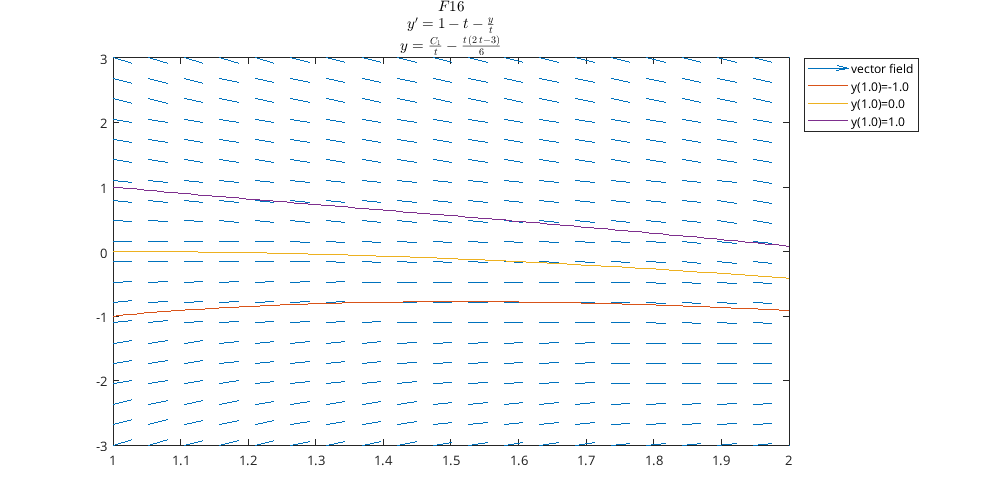

In [259]:
p1_one(p1_feladatok.f16,0.3)